# Read JSONL + Plot
Simple notebook: load scored JSONL and plot one column.

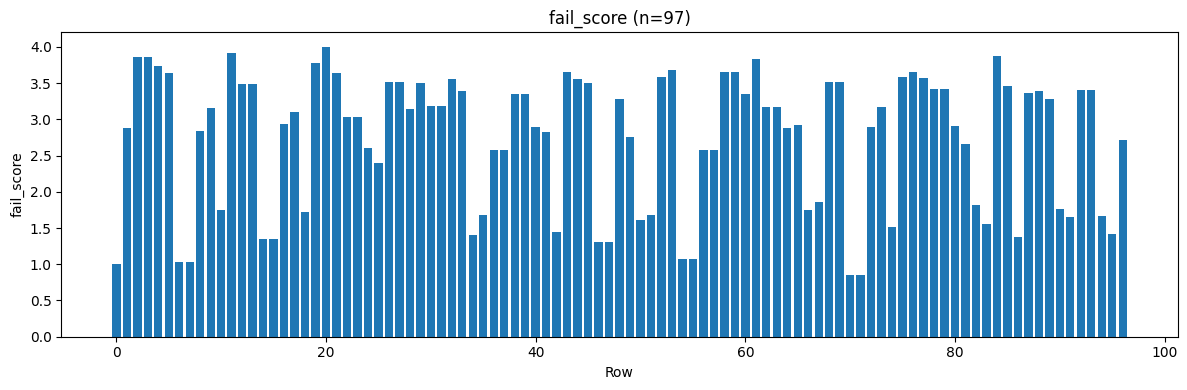

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
COL = "fail_score"  # change if needed

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df[COL] = pd.to_numeric(df[COL], errors="coerce")
d = df.dropna(subset=[COL]).reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.bar(range(len(d)), d[COL].to_list())
plt.title(f"{COL} (n={len(d)})")
plt.xlabel("Row")
plt.ylabel(COL)
plt.tight_layout()
plt.show()



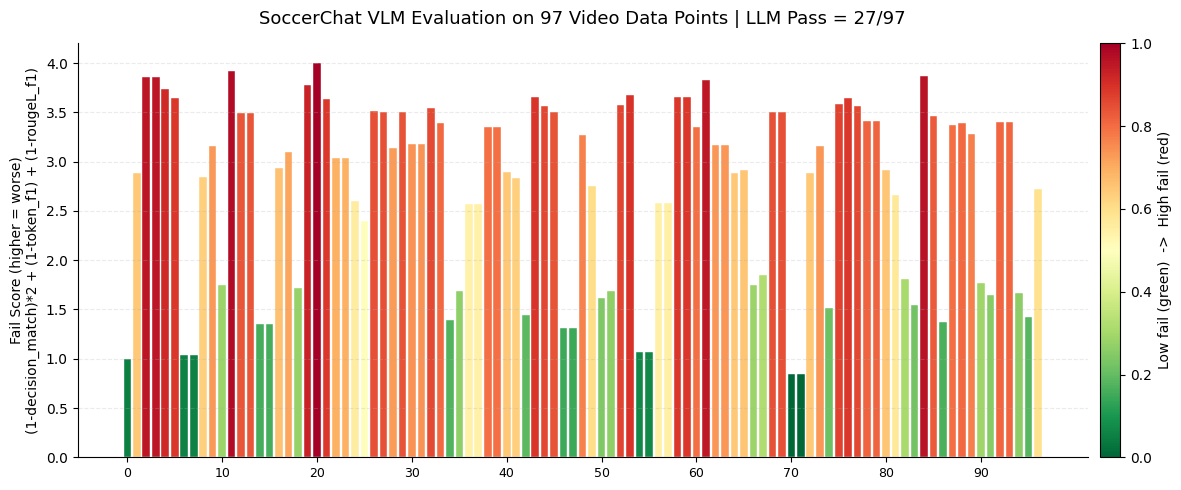

In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
COL = "fail_score"
rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))
df = pd.DataFrame(rows)
df[COL] = pd.to_numeric(df[COL], errors="coerce")
d = df.dropna(subset=[COL]).reset_index(drop=True)
pass_count = None
if "judge_score_llm" in d.columns:
    j = pd.to_numeric(d["judge_score_llm"], errors="coerce")
    pass_count = int((j == 1).sum())
vals = d[COL].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
den = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / den
colors = plt.cm.RdYlGn_r(norm)
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.3)
title = f"SoccerChat VLM Evaluation on {n} Video Data Points"
if pass_count is not None:
    title += f" | LLM Pass = {pass_count}/{n}"
ax.set_title(title, fontsize=13, pad=14)
ax.set_xlabel(
    "Each bar = one case. decision_match: exact decision correct (0/1); "
    "token_f1: token overlap between prediction and ground truth; "
    "rougeL_f1: sequence-level overlap (longest common subsequence) F1.",
    fontsize=10,
    labelpad=10,
)
ax.set_ylabel(
    "Fail Score (higher = worse)\n"
    "(1-decision_match)*2 + (1-token_f1) + (1-rougeL_f1)",
    fontsize=10,
)
xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")
plt.tight_layout()
plt.show()




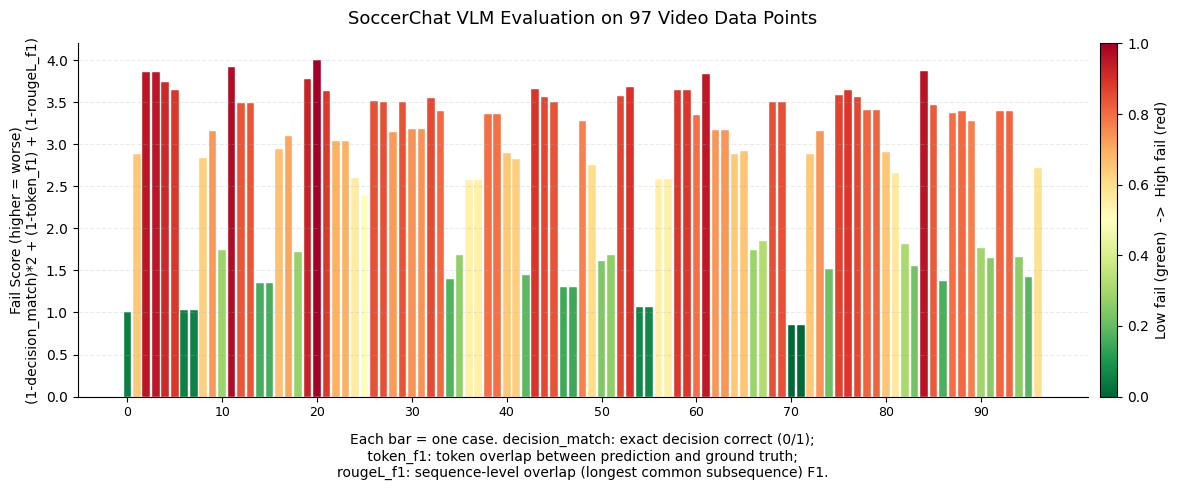

In [3]:
# New cell: updated bottom explanation text
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
COL = "fail_score"

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df[COL] = pd.to_numeric(df[COL], errors="coerce")
d = df.dropna(subset=[COL]).reset_index(drop=True)

vals = d[COL].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.3)

ax.set_title(f"SoccerChat VLM Evaluation on {n} Video Data Points", fontsize=13, pad=14)
ax.set_xlabel(
    "Each bar = one case. decision_match: exact decision correct (0/1);\n "
    "token_f1: token overlap between prediction and ground truth; \n"
    "rougeL_f1: sequence-level overlap (longest common subsequence) F1.",
    fontsize=10,
    labelpad=10,
)
ax.set_ylabel(
    "Fail Score (higher = worse)\n"
    "(1-decision_match)*2 + (1-token_f1) + (1-rougeL_f1)",
    fontsize=10,
)

xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=9)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

plt.tight_layout()
plt.show()




In [ ]:
# Clean replacement cell: error-combo distribution (syntax-safe)
import json
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

combo_counts = Counter(combo_list)
combo_df = pd.DataFrame({
    "error_combo": list(combo_counts.keys()),
    "cases": list(combo_counts.values()),
}).sort_values("cases", ascending=False).reset_index(drop=True)
combo_df["pct_cases"] = (100.0 * combo_df["cases"] / max(1, len(df))).round(1)

print(f"Total cases: {len(df)}")
print(f"Unique combinations: {len(combo_df)}")
print(combo_df.to_string(index=False))

# Plot top 12 combos
plot_df = combo_df.head(12)
plt.figure(figsize=(13, 5))
plt.barh(plot_df["error_combo"], plot_df["cases"], color="#7c3aed", alpha=0.9)
plt.gca().invert_yaxis()
plt.title(f"Error Tag Combination Distribution (Top {len(plot_df)})")
plt.xlabel("Cases")
plt.ylabel("Tag combination")
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()

combo_df



In [ ]:
# Error-tag combination distribution (full code)

import json
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

# One combo label per case
combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

combo_counts = Counter(combo_list)
combo_df = pd.DataFrame({
    "error_combo": list(combo_counts.keys()),
    "cases": list(combo_counts.values()),
}).sort_values("cases", ascending=False).reset_index(drop=True)

combo_df["pct_cases"] = (100.0 * combo_df["cases"] / max(1, len(df))).round(1)

print(f"Total cases: {len(df)}")
print(f"Unique combinations: {len(combo_df)}")
print(combo_df.to_string(index=False))

# Plot top 12 combinations
plot_df = combo_df.head(12)

plt.figure(figsize=(13, 5))
plt.barh(plot_df["error_combo"], plot_df["cases"], color="#7c3aed", alpha=0.9)
plt.gca().invert_yaxis()
plt.title(f"Error Tag Combination Distribution (Top {len(plot_df)})")
plt.xlabel("Cases")
plt.ylabel("Tag combination")
plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()

combo_df



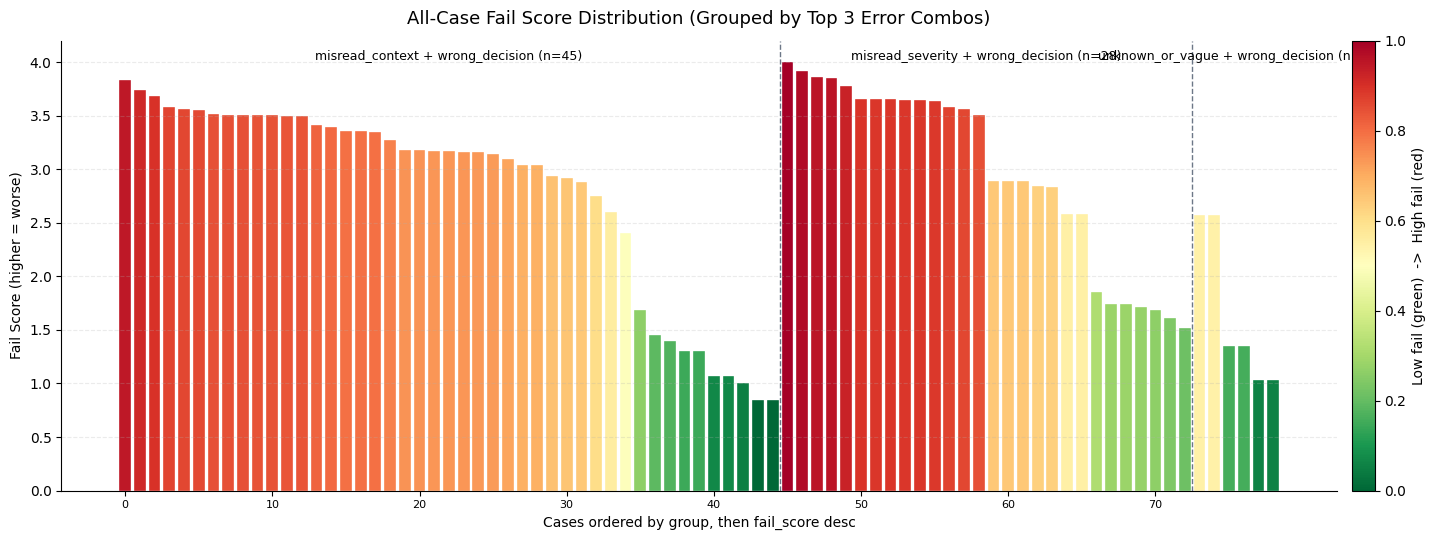

,group,n_cases,mean_fail,min_fail,max_fail
0,misread_context + wrong_decision,45,2.809362,0.849899,3.832653
1,misread_severity + wrong_decision,28,2.976559,1.515197,4.000000
2,unknown_or_vague + wrong_decision,6,1.652268,1.033493,2.571429


In [2]:
# New cell: all-case grouped vertical bars with separators (by error combo)
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS = 3  # top error-combo groups, rest -> "other"

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)


def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

# Build combo label per case
combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list

# Keep top groups, collapse rest into 'other'
combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

# Group order: top groups first, then other
group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])

parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)
plot_df = pd.concat(parts, axis=0).reset_index(drop=True)

vals = plot_df["fail_score"].to_numpy()
n = len(vals)

# green (low fail) -> red (high fail)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.25)

# separators and group labels
start = 0
for g in group_order:
    m = (plot_df["group"] == g).sum()
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.98 if ax.get_ylim()[1] > 0 else 0.98, f"{g} (n={m})",
            ha="center", va="top", fontsize=9, rotation=0)
    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.8)
    start = end

ax.set_title(f"All-Case Fail Score Distribution (Grouped by Top {TOP_GROUPS} Error Combos)", fontsize=13, pad=12)
ax.set_xlabel("Cases ordered by group, then fail_score desc", fontsize=10)
ax.set_ylabel("Fail Score (higher = worse)", fontsize=10)

# keep x minimal for readability
xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

plt.tight_layout()
plt.show()

# show group summary table
summary = plot_df.groupby("group", as_index=False).agg(
    n_cases=("fail_score", "size"),
    mean_fail=("fail_score", "mean"),
    min_fail=("fail_score", "min"),
    max_fail=("fail_score", "max"),
)
summary = summary.sort_values("n_cases", ascending=False).reset_index(drop=True)
summary



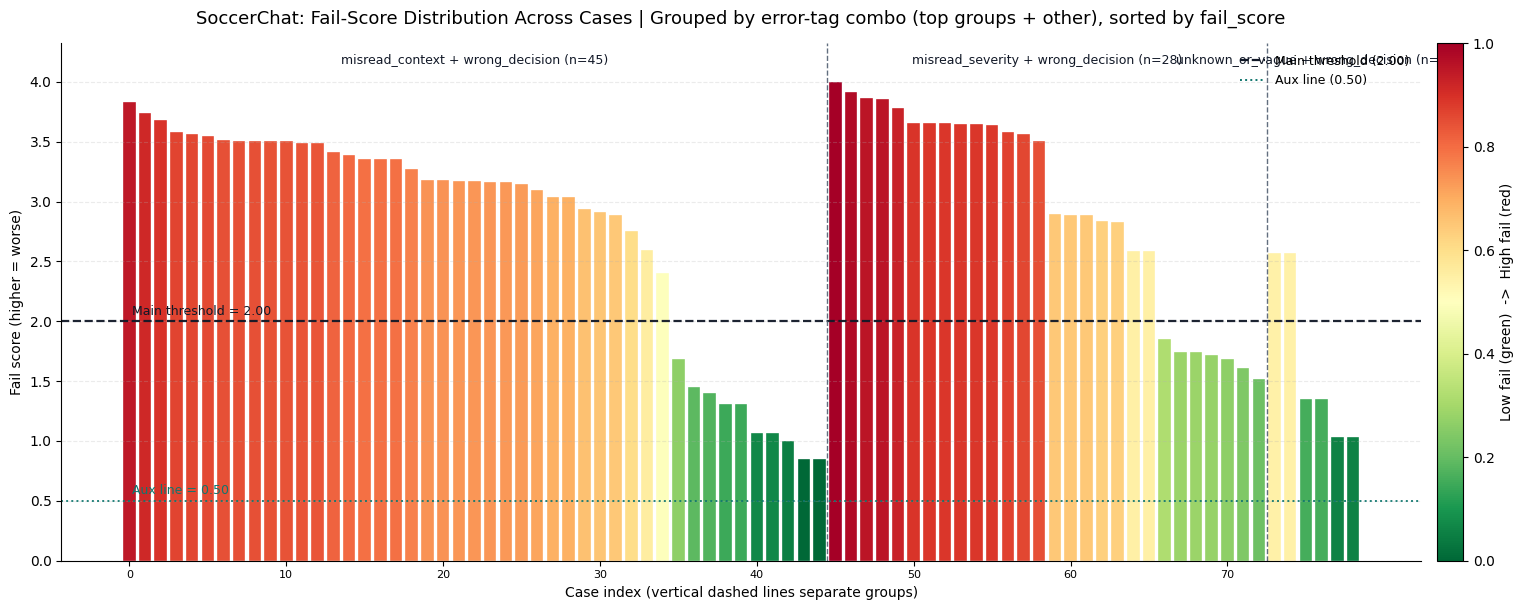

,group,n_cases,mean_fail,median_fail,min_fail,max_fail
0,misread_context + wrong_decision,45,2.809362,3.170009,0.849899,3.832653
1,misread_severity + wrong_decision,28,2.976559,3.200644,1.515197,4.000000
2,unknown_or_vague + wrong_decision,6,1.652268,1.351882,1.033493,2.571429


In [5]:
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS = 3
MAIN_THRESH = 2.0
AUX_THRESH = 0.5
SHOW_AUX = True

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list
combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])
parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)

plot_df = pd.concat(parts, axis=0).reset_index(drop=True)
vals = plot_df["fail_score"].to_numpy()
n = len(vals)

vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(17, 6.2))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.25)

ax.axhline(MAIN_THRESH, color="#111827", linestyle="--", linewidth=1.6, alpha=0.95)
ax.text(0.2, MAIN_THRESH + 0.03, f"Main threshold = {MAIN_THRESH:.2f}", fontsize=9, color="#111827", va="bottom")

if SHOW_AUX:
    ax.axhline(AUX_THRESH, color="#0f766e", linestyle=":", linewidth=1.4, alpha=0.9)
    ax.text(0.2, AUX_THRESH + 0.03, f"Aux line = {AUX_THRESH:.2f}", fontsize=9, color="#0f766e", va="bottom")

ax.set_ylim(0, max(float(np.nanmax(vals)) * 1.08, MAIN_THRESH + 0.25))

start = 0
for g in group_order:
    m = int((plot_df["group"] == g).sum())
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.98, f"{g} (n={m})", ha="center", va="top", fontsize=9, color="#111827")
    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.85)
    start = end

ax.set_title(
    "SoccerChat: Fail-Score Distribution Across Cases | Grouped by error-tag combo (top groups + other), sorted by fail_score",
    fontsize=13,
    pad=14,
)
ax.set_xlabel("Case index (vertical dashed lines separate groups)", fontsize=10)
ax.set_ylabel("Fail score (higher = worse)", fontsize=10)

xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

legend_handles = [Line2D([0], [0], color="#111827", lw=1.6, ls="--", label=f"Main threshold ({MAIN_THRESH:.2f})")]
if SHOW_AUX:
    legend_handles.append(Line2D([0], [0], color="#0f766e", lw=1.4, ls=":", label=f"Aux line ({AUX_THRESH:.2f})"))
ax.legend(handles=legend_handles, frameon=False, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

summary = plot_df.groupby("group", as_index=False).agg(
    n_cases=("fail_score", "size"),
    mean_fail=("fail_score", "mean"),
    median_fail=("fail_score", "median"),
    min_fail=("fail_score", "min"),
    max_fail=("fail_score", "max"),
).sort_values("n_cases", ascending=False).reset_index(drop=True)
summary



In [ ]:
# New cell: same grouped plot, but group labels use two lines
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS = 3

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list
combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])
parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)
plot_df = pd.concat(parts, axis=0).reset_index(drop=True)

vals = plot_df["fail_score"].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(17, 6))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.25)
ax.set_ylim(0, max(float(np.nanmax(vals)) * 1.08, 2.3))

start = 0
for g in group_order:
    m = int((plot_df["group"] == g).sum())
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2
    # Two-line label
    ax.text(mid, ax.get_ylim()[1] * 0.98, f"{g}
(n={m})", ha="center", va="top", fontsize=9, color="#111827")
    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.85)
    start = end

ax.set_title("Grouped Fail-Score Distribution (two-line group labels)", fontsize=13, pad=12)
ax.set_xlabel("Case index", fontsize=10)
ax.set_ylabel("Fail score (higher = worse)", fontsize=10)

xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

plt.tight_layout()
plt.show()



In [ ]:
# New cell: non-overlapping two-line group labels (staggered)
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS = 3

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

def short_label(s, max_len=22):
    s = str(s)
    return s if len(s) <= max_len else (s[:max_len-3] + "...")

combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list
combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])
parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)
plot_df = pd.concat(parts, axis=0).reset_index(drop=True)

vals = plot_df["fail_score"].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(17, 6.4))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.25)
ax.set_ylim(0, max(float(np.nanmax(vals)) * 1.14, 2.5))

start = 0
label_y_hi = ax.get_ylim()[1] * 0.985
label_y_lo = ax.get_ylim()[1] * 0.93
for i, g in enumerate(group_order):
    m = int((plot_df["group"] == g).sum())
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2
    y = label_y_hi if (i % 2 == 0) else label_y_lo
    txt = f"{short_label(g)}\n(n={m})"
    ax.text(mid, y, txt, ha="center", va="top", fontsize=8, color="#111827",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7))
    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.85)
    start = end

ax.set_title("Grouped Fail-Score Distribution (staggered two-line group labels)", fontsize=13, pad=12)
ax.set_xlabel("Case index", fontsize=10)
ax.set_ylabel("Fail score (higher = worse)", fontsize=10)

xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

plt.tight_layout()
plt.show()



In [ ]:
# New cell: fit-safe grouped plot (short IDs on chart + full legend table)
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS = 3

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list
combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])
parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)
plot_df = pd.concat(parts, axis=0).reset_index(drop=True)

# Group IDs for compact labels
id_map = {g: f"G{i+1}" for i, g in enumerate(group_order)}

vals = plot_df["fail_score"].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(17, 5.8))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.25)
ax.set_ylim(0, max(float(np.nanmax(vals)) * 1.12, 2.4))

start = 0
for g in group_order:
    m = int((plot_df["group"] == g).sum())
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.98, f"{id_map[g]}\n(n={m})", ha="center", va="top", fontsize=8)
    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.85)
    start = end

ax.set_title("Grouped Fail-Score Distribution (fit-safe labels)", fontsize=13, pad=12)
ax.set_xlabel("Case index", fontsize=10)
ax.set_ylabel("Fail score (higher = worse)", fontsize=10)
xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

plt.tight_layout()
plt.show()

# Full label table (no clipping)
legend_rows = []
for g in group_order:
    m = int((plot_df["group"] == g).sum())
    legend_rows.append({"group_id": id_map[g], "full_group_label": g, "n_cases": m})
legend_df = pd.DataFrame(legend_rows)
legend_df



In [ ]:
# New cell: group labels as two-line error phrases (first two tags)
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS = 3

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list
combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])
parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)
plot_df = pd.concat(parts, axis=0).reset_index(drop=True)

# Two-line label from combo text
# e.g., "wrong_decision + misread_context" ->
# line1: wrong_decision
# line2: misread_context

def two_line_label(group_name):
    if group_name == "other":
        return "other
(mixed)"
    parts = [x.strip() for x in str(group_name).split("+") if x.strip()]
    if len(parts) == 0:
        return "no_tag
(n/a)"
    if len(parts) == 1:
        return f"{parts[0]}\n(n/a)"
    return f"{parts[0]}\n{parts[1]}"

vals = plot_df["fail_score"].to_numpy()
n = len(vals)
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(17, 6.2))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.25)
ax.set_ylim(0, max(float(np.nanmax(vals)) * 1.14, 2.5))

start = 0
for i, g in enumerate(group_order):
    m = int((plot_df["group"] == g).sum())
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2
    y = ax.get_ylim()[1] * (0.98 if i % 2 == 0 else 0.93)
    ax.text(
        mid, y, two_line_label(g) + f"\n(n={m})",
        ha="center", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7),
    )
    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.85)
    start = end

ax.set_title("Grouped Fail-Score Distribution (two-line group error labels)", fontsize=13, pad=12)
ax.set_xlabel("Case index", fontsize=10)
ax.set_ylabel("Fail score (higher = worse)", fontsize=10)
xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

plt.tight_layout()
plt.show()



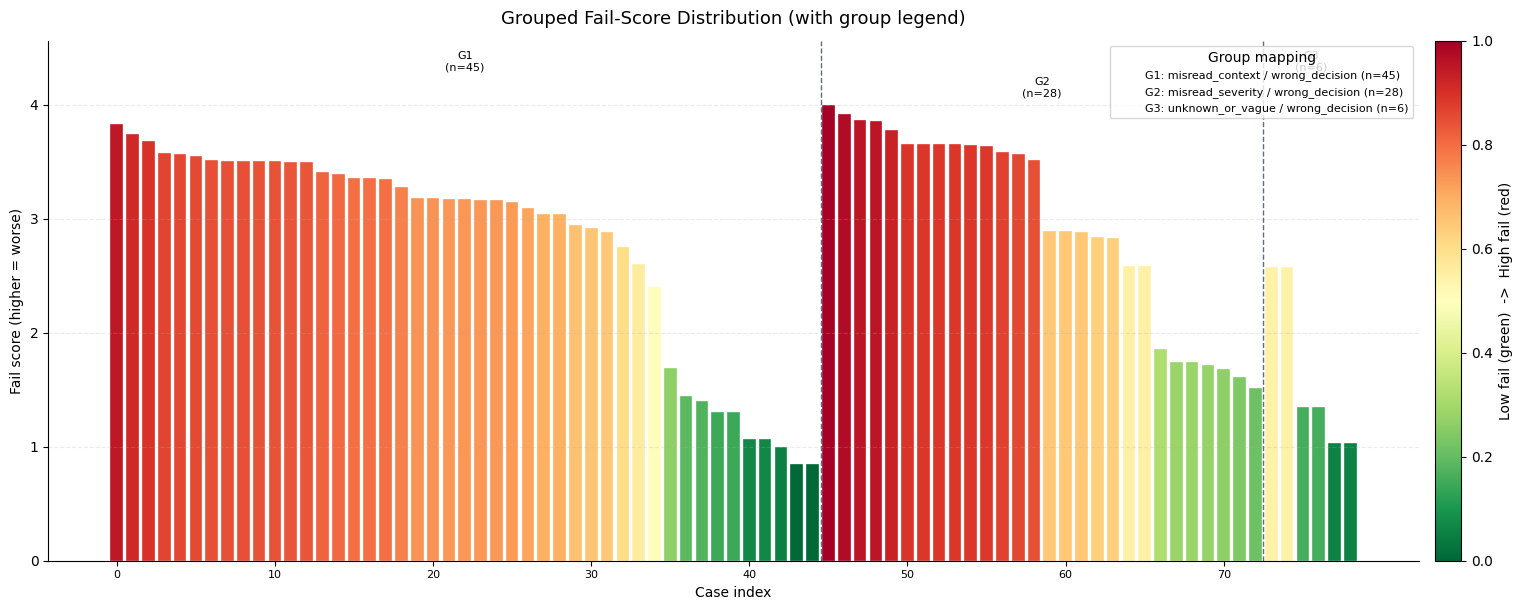

In [13]:
# New cell: grouped plot + configurable legend for group text
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DATA_PATH = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS = 3
LEGEND_LOC = "upper right"   # try: "upper right", "lower right", "upper left", "lower left"

rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)

def tags_from_value(v):
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    return []

def two_line_label(group_name):
    if group_name == "other":
        return "other\n(mixed)"
    parts = [x.strip() for x in str(group_name).split("+") if x.strip()]
    if len(parts) == 0:
        return "no_tag\n(n/a)"
    if len(parts) == 1:
        return f"{parts[0]}\n(n/a)"
    return f"{parts[0]}\n{parts[1]}"

combo_list = []
for v in df.get("error_tags", []):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list
combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])
parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)
plot_df = pd.concat(parts, axis=0).reset_index(drop=True)

vals = plot_df["fail_score"].to_numpy()
n = len(vals)

vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
denom = (vmax - vmin) if vmax > vmin else 1.0
norm = (vals - vmin) / denom
colors = plt.cm.RdYlGn_r(norm)

fig, ax = plt.subplots(figsize=(17, 6.2))
ax.bar(np.arange(n), vals, color=colors, edgecolor="white", linewidth=0.25)
ax.set_ylim(0, max(float(np.nanmax(vals)) * 1.14, 2.5))

start = 0
legend_rows = []
for i, g in enumerate(group_order):
    m = int((plot_df["group"] == g).sum())
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2
    y = ax.get_ylim()[1] * (0.98 if i % 2 == 0 else 0.93)
    short_txt = f"G{i+1}\n(n={m})"
    ax.text(
        mid, y, short_txt,
        ha="center", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7),
    )
    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.85)
    legend_rows.append((f"G{i+1}", two_line_label(g), m))
    start = end

ax.set_title("Grouped Fail-Score Distribution (with group legend)", fontsize=13, pad=12)
ax.set_xlabel("Case index", fontsize=10)
ax.set_ylabel("Fail score (higher = worse)", fontsize=10)
xt = np.arange(0, n, 10)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Colorbar for fail score
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Low fail (green)  ->  High fail (red)")

# Legend for group text (top-right by default)
handles = []
for gid, gtext, m in legend_rows:
    label = f"{gid}: {gtext.replace(chr(10), ' / ')} (n={m})"
    handles.append(Patch(facecolor='none', edgecolor='none', label=label))
ax.legend(handles=handles, loc=LEGEND_LOC, frameon=True, fontsize=8, title="Group mapping")

plt.tight_layout()
plt.show()



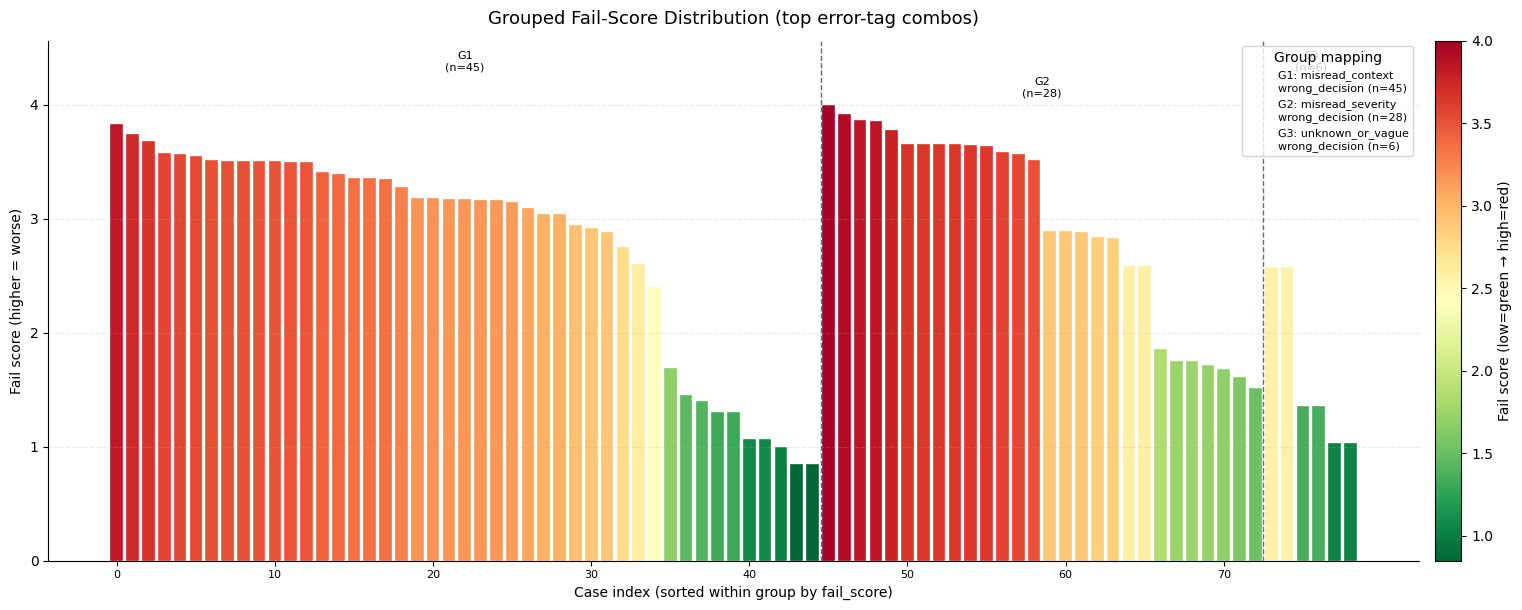

Loaded rows: 79 | plotted: 79
Top groups: ['misread_context + wrong_decision', 'misread_severity + wrong_decision', 'unknown_or_vague + wrong_decision']


In [ ]:
# Grouped fail-score plot by top error-tag combinations (robust)
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import colors as mcolors

# ==========================
# CONFIG
# ==========================
DATA_PATH   = Path(r"C:/Users/adams/Documents/Projects/soccerchat/SoccerChat_valid_xfoul_abs_preds_100_scored_v4.jsonl")
TOP_GROUPS  = 3
LEGEND_LOC  = "upper right"   # "upper right", "lower right", "upper left", "lower left"
XTICK_EVERY = 10

# Optional filters (set to None/False to disable)
ONLY_DECISION_FAILED = False    # True => keep only decision_match==0 (or judge_score_regex==0 fallback)
MIN_FAIL_SCORE       = None     # e.g., 2.0 to focus on worst only

# ==========================
# LOAD
# ==========================
rows = []
with DATA_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)

# --------------------------
# Robust numeric columns
# --------------------------
df["fail_score"] = pd.to_numeric(df.get("fail_score"), errors="coerce")

# decision_match fallback logic
if "decision_match" in df.columns:
    df["decision_match_num"] = pd.to_numeric(df["decision_match"], errors="coerce")
else:
    df["decision_match_num"] = np.nan

if "judge_score_regex" in df.columns:
    rx = pd.to_numeric(df["judge_score_regex"], errors="coerce")
    df["decision_match_num"] = df["decision_match_num"].fillna(rx)

# keep rows with valid fail_score
df = df.dropna(subset=["fail_score"]).reset_index(drop=True)

# optional filters
if ONLY_DECISION_FAILED:
    df = df[df["decision_match_num"] == 0].copy()

if MIN_FAIL_SCORE is not None:
    df = df[df["fail_score"] >= float(MIN_FAIL_SCORE)].copy()

df = df.reset_index(drop=True)

# ==========================
# Helpers: tags parsing + labeling
# ==========================
def tags_from_value(v):
    # v can be list, string, None
    if isinstance(v, list):
        out = []
        for x in v:
            s = str(x).strip()
            if s:
                out.append(s)
        return out
    if isinstance(v, str):
        s = v.strip()
        if not s:
            return []
        # allow "a,b" or "a; b" or "a + b"
        for sep in [",", ";", "|", "+"]:
            if sep in s:
                parts = [p.strip() for p in s.split(sep)]
                return [p for p in parts if p]
        return [s]
    return []

def two_line_label(group_name):
    if group_name == "other":
        return "other\n(mixed)"
    if group_name == "no_tag":
        return "no_tag\n(n/a)"
    parts = [x.strip() for x in str(group_name).split("+") if x.strip()]
    if len(parts) == 0:
        return "no_tag\n(n/a)"
    if len(parts) == 1:
        return f"{parts[0]}\n(n/a)"
    return f"{parts[0]}\n{parts[1]}"

# ==========================
# Build combo groups
# ==========================
combo_list = []
for v in df.get("error_tags", pd.Series([None]*len(df))):
    tags = sorted(set(tags_from_value(v)))
    combo_list.append(" + ".join(tags) if tags else "no_tag")

df["error_combo"] = combo_list

combo_counts = Counter(df["error_combo"].tolist())
keep = [k for k, _ in combo_counts.most_common(TOP_GROUPS)]
df["combo_group"] = df["error_combo"].apply(lambda x: x if x in keep else "other")

group_order = keep + (["other"] if (df["combo_group"] == "other").any() else [])

# ==========================
# Order rows: by group, worst->best within group
# ==========================
parts = []
for g in group_order:
    sub = df[df["combo_group"] == g].sort_values("fail_score", ascending=False).copy()
    sub["group"] = g
    parts.append(sub)

plot_df = pd.concat(parts, axis=0).reset_index(drop=True)

vals = plot_df["fail_score"].to_numpy()
n = len(vals)

if n == 0:
    raise RuntimeError("No rows left after filtering. Relax ONLY_DECISION_FAILED / MIN_FAIL_SCORE.")

# ==========================
# Colors + plot
# ==========================
vmin, vmax = float(np.nanmin(vals)), float(np.nanmax(vals))
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlGn_r
bar_colors = cmap(norm(vals))

fig, ax = plt.subplots(figsize=(17, 6.2))
ax.bar(np.arange(n), vals, color=bar_colors, edgecolor="white", linewidth=0.25)

ax.set_ylim(0, max(vmax * 1.14, 2.5))

start = 0
legend_rows = []

for i, g in enumerate(group_order):
    m = int((plot_df["group"] == g).sum())
    if m == 0:
        continue
    end = start + m
    mid = (start + end - 1) / 2

    y = ax.get_ylim()[1] * (0.98 if i % 2 == 0 else 0.93)
    short_txt = f"G{i+1}\n(n={m})"
    ax.text(
        mid, y, short_txt,
        ha="center", va="top", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7),
    )

    if end < n:
        ax.axvline(end - 0.5, color="#475569", linestyle="--", linewidth=1.0, alpha=0.85)

    legend_rows.append((f"G{i+1}", two_line_label(g), m))
    start = end

ax.set_title("Grouped Fail-Score Distribution (top error-tag combos)", fontsize=13, pad=12)
ax.set_xlabel("Case index (sorted within group by fail_score)", fontsize=10)
ax.set_ylabel("Fail score (higher = worse)", fontsize=10)

xt = np.arange(0, n, XTICK_EVERY)
ax.set_xticks(xt)
ax.set_xticklabels([str(i) for i in xt], fontsize=8)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Proper colorbar (uses same normalization as bars)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Fail score (low=green → high=red)")

# Group legend (text-only)
handles = []
for gid, gtext, m in legend_rows:
    label = f"{gid}: {gtext.replace(chr(10), ' / ')} (n={m})"
    handles.append(Patch(facecolor="none", edgecolor="none", label=label))

ax.legend(handles=handles, loc=LEGEND_LOC, frameon=True, fontsize=8, title="Group mapping")

plt.tight_layout()
plt.show()

print(f"Loaded rows: {len(df)} | plotted: {n}")
print("Top groups:", keep)